## The Normal Equation

The expression of the solution Θ that minimises MSE(Θ) is known
as the normal equation:


The normal equation is expressed as:

$$\Theta = (X^T \cdot X)^{-1} \cdot X^T \cdot y$$

Where:
*   $\Theta$ represents the vector of parameters that minimize the Mean Squared Error (MSE).
*   $X$ is the design matrix, containing the features of the training data.
*   $X^T$ is the transpose of the design matrix.
*   $y$ is the vector of target values from $y^{(i)}$ to $y^{(m)}$.
*   $(X^T \cdot X)^{-1}$ is the inverse of the matrix product $X^T \cdot X$.

In [1]:
# Create a "linear-looking" data using a random plot

import numpy as np

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

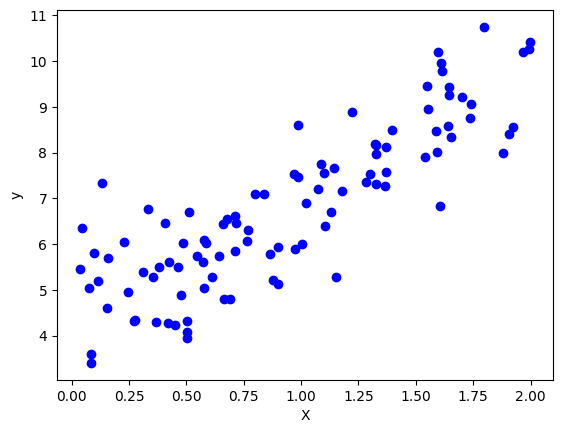

In [2]:
# Plot using mtplotlib

import matplotlib.pyplot as plt

plt.ylabel('y')
plt.xlabel('X')

plt.plot(X, y, 'bo')
plt.show()

Compute $\Theta$

In [3]:
# Compute $$\Theta

X_b = np.c_[np.ones((100, 1)), X] # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best

array([[4.29828531],
       [2.66190324]])

Make predictions using $\Theta$

In [4]:
# Make predictions using $$\Theta

X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
y_predict = X_new_b.dot(theta_best)

In [5]:
y_predict

array([[4.29828531],
       [9.62209179]])

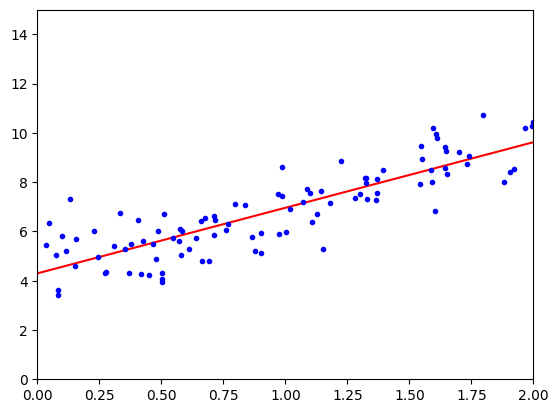

In [6]:
# Plot the model's predictions

plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

## Using scikit-learn's Linear Regression

In [7]:
# Equivalently, using scikit-learn's Linear Regression

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.29828531]), array([[2.66190324]]))

## Batch Gradient Descent

In [8]:
# An easy implementation using numpy

eta = 0.1 # learning rate
n_iterations = 1000
m = 100

theta = np.random.randn(2, 1) # random initialization

for iteration in range(n_iterations):
  gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
  theta = theta - eta * gradients

# The resulting theta
theta

array([[4.29828531],
       [2.66190324]])

## Stochastic Gradient Descent

In [9]:
# Implementation of SGD using a simple learning schedule

n_epochs = 50
t0, t1 = 5, 50 # learning schedule hyperparameters

def learning_schedule(t):
  return t0 / (t + t1)

theta = np.random.randn(2, 1) # random initialization

for epoch in range(n_epochs):
  for i in range(m):
    random_index = np.random.randint(m)
    xi = X_b[random_index:random_index+1]
    yi = y[random_index:random_index+1]
    gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
    eta = learning_schedule(epoch * m + i)
    theta = theta - eta * gradients

theta

array([[4.35028175],
       [2.63550596]])

## Using scikit-learn's SGDRegressor

In [10]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=50, penalty=None, eta0=0.01)
sgd_reg.fit(X, y.ravel())

sgd_reg.intercept_, sgd_reg.coef_

(array([3.91738714]), array([3.00822029]))

Using Polynomial Features in Scikit-learn

In [11]:
# Polynomial regression is used when we have a non-linear looking data

m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

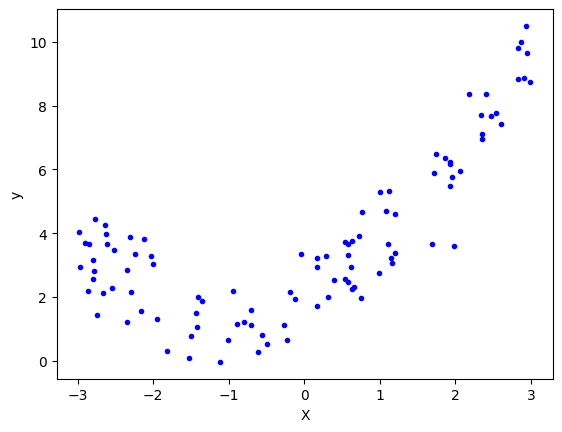

In [12]:
plt.plot(X, y, 'b.')
plt.ylabel('y')
plt.xlabel('X')
plt.show()

In [13]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

print(X[:5])

[[-2.90543132]
 [ 1.93326282]
 [ 1.85744971]
 [ 1.98391948]
 [-0.55977006]]


In [14]:
# Fit linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.99138736]), array([[1.04785084, 0.52975662]]))

## Ridge Regression

In [15]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([5.21909145])

Comapring with Stochastic Gradient

In [16]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(penalty="l2") # penalty="l2" is similar to ridge
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([5.1937233])

## Lasso Regression

In [17]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([5.17804003])

Elastic Net

In [18]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([5.18025802])

## Logistic Regression

Example Through the Iris Dataset

In [19]:
from sklearn import datasets

iris = datasets.load_iris()
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [23]:
X = iris["data"][:, 3:] # Petal width
y = (iris["target"] == 2).astype(np.int32) # 1 if Iris-Virginica, else 0"

Train the logistic model using LogisticRegression class

In [26]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X, y)

LogisticRegression()

## Softmax Regression

In [28]:
X = iris["data"][:, (2, 3)]
y = iris["target"] # petal length, petal width

softmax_reg = LogisticRegression(solver="lbfgs", C=10) # multi_class="multinomial",
softmax_reg.fit(X, y)

softmax_reg.predict_proba([[5, 2]])

array([[6.21626374e-07, 5.73689802e-02, 9.42630398e-01]])

In [29]:
softmax_reg.predict([[5, 2]])

array([2])